<a href="https://colab.research.google.com/github/amruthavinodck/customer-churn-prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Customer Churn Prediction

**Amrutha Vinod**

## Business Problem

Telecom companies lose revenue when customers cancel their subscription ("churn"). It's far cheaper to retain an existing customer with a targeted offer than to acquire a new one.

This project builds a model that flags customers who are likely to churn before they leave, so the retention team can act early.

## Approach

1. Load & clean customer data
2. Explore patterns (EDA) — what actually drives churn?
3. Encode categorical features for ML
4. Train two models: Logistic Regression (interpretable baseline) and Random Forest (captures non-linear patterns)
5. Evaluate with Accuracy, Precision, Recall, F1, and ROC-AUC — not just accuracy, since the business cares more about catching churners (recall) than raw accuracy
6. Identify the top features driving churn to give the business actionable insights

## Dataset

The dataset is synthetically generated for this project, using realistic telecom churn patterns such as contract type, tenure, and charges. It follows the same general structure as the widely used Telco Customer Churn dataset.

In [14]:
from google.colab import files
uploaded = files.upload()

Saving telecom_churn.csv to telecom_churn (4).csv


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Import libraries

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve)
sns.set_style("whitegrid")

## 2. Load the data

In [20]:
df = pd.read_csv("telecom_churn.csv")
print("Shape:", df.shape)
df.head()

Shape: (2000, 14)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaymentMethod,InternetService,TechSupport,OnlineSecurity,MonthlyCharges,TotalCharges,Churn
0,CUST1000,Male,0,No,No,56,Month-to-month,Electronic check,DSL,No,No,96.36,5407.82,Yes
1,CUST1001,Female,0,No,No,26,Month-to-month,Mailed check,DSL,No,No,58.90,1513.61,No
2,CUST1002,Male,1,Yes,No,4,Month-to-month,Mailed check,DSL,Yes,Yes,101.24,448.73,Yes
3,CUST1003,Male,0,No,No,70,Month-to-month,Mailed check,DSL,No,No,90.25,6301.98,Yes
4,CUST1004,Male,0,No,No,56,Month-to-month,Bank transfer,DSL,No,Yes,102.53,5621.52,Yes


## 3. Data Cleaning`TotalCharges` has a few missing values (common in real billing data — usually new customers with $0 total or a data-entry gap). I fill these with the **median** rather than mean, since it's more robust to outliers (a few very high-spend customers would skew the mean).

In [22]:
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())
df_model = df.drop(columns=["customerID"])  # ID has no predictive value
print("\nMissing values after cleaning:", df_model.isnull().sum().sum())

Missing values before cleaning:
TotalCharges    15
dtype: int64

Missing values after cleaning: 0


## 4. Exploratory Data Analysis (EDA)Before modeling, I look for patterns a human can already sense — this also helps sanity-check the model later (if the model's top features don't match what EDA shows, something's wrong).

/tmp/ipykernel_1237/1294864433.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1,1], palette=["#2E86AB","#E63946"])


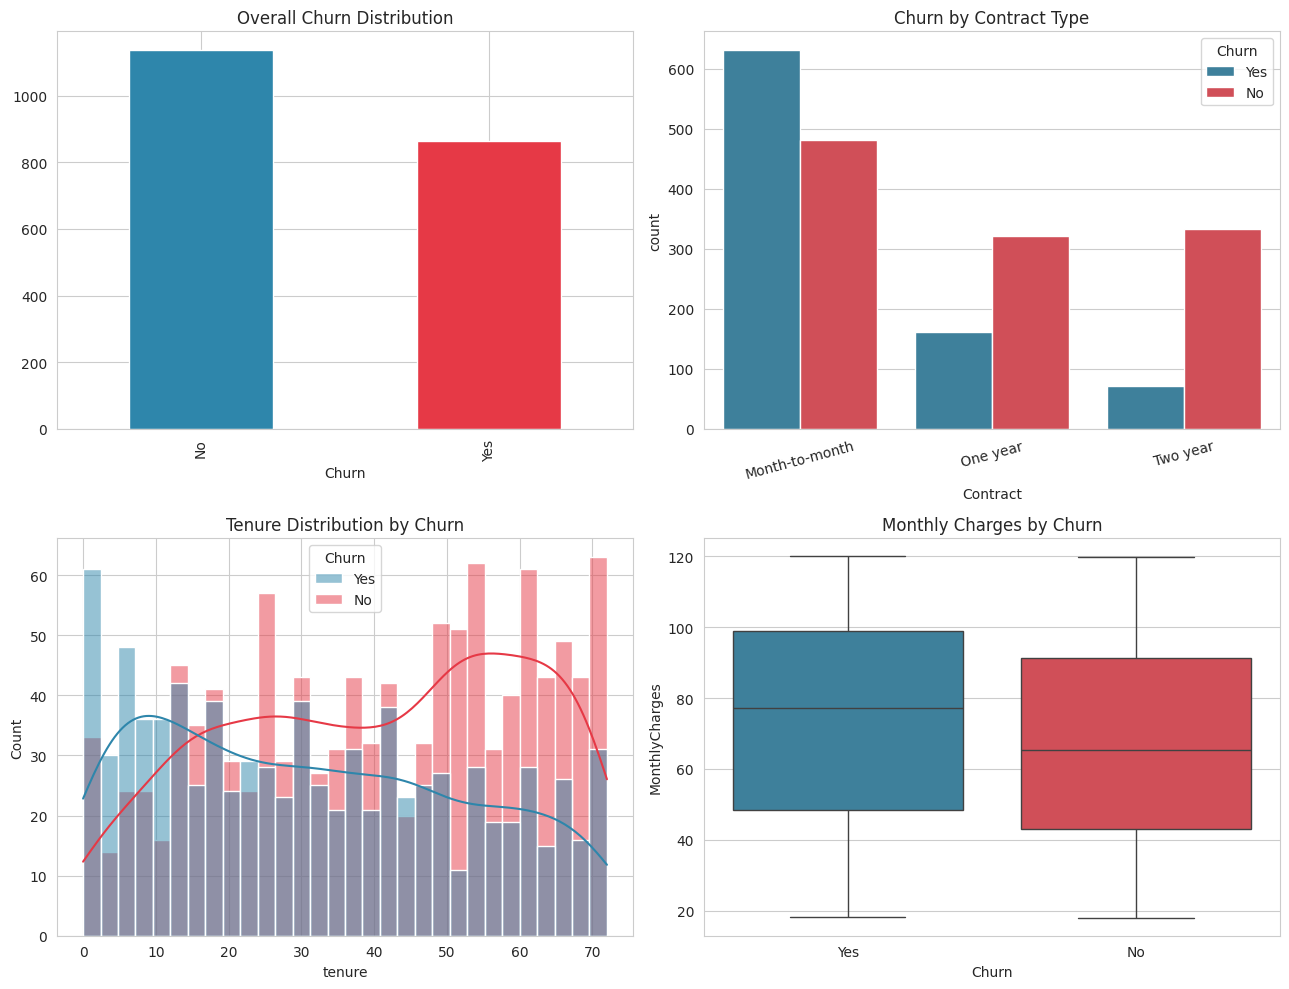

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
df["Churn"].value_counts().plot(kind="bar", ax=axes[0,0], color=["#2E86AB","#E63946"])
axes[0,0].set_title("Overall Churn Distribution")
sns.countplot(data=df, x="Contract", hue="Churn", ax=axes[0,1], palette=["#2E86AB","#E63946"])
axes[0,1].set_title("Churn by Contract Type")
axes[0,1].tick_params(axis="x", rotation=15)
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, ax=axes[1,0], palette=["#2E86AB","#E63946"])
axes[1,0].set_title("Tenure Distribution by Churn")
sns.boxplot(data=df, x="Churn", y="MonthlyCharges", ax=axes[1,1], palette=["#2E86AB","#E63946"])
axes[1,1].set_title("Monthly Charges by Churn")
plt.tight_layout()
plt.show()

**Key insight:** Month-to-month customers churn far more than one/two-year contract customers, and churners skew toward **lower tenure** (newer customers) and **higher monthly charges**. This already tells the business something actionable: push longer contracts and watch new, high-bill customers closely.

In [26]:
churn_by_contract = df.groupby("Contract")["Churn"].apply(lambda x: (x=="Yes").mean())
print("Churn rate by contract type:")
print(churn_by_contract.round(3))

Churn rate by contract type:
Contract
Month-to-month    0.567
One year          0.335
Two year          0.176
Name: Churn, dtype: float64


## 5. Encode categorical variablesModels need numbers, not text. I use **one-hot encoding** (`pd.get_dummies`) for categorical columns like Contract and PaymentMethod, dropping the first category of each to avoid the "dummy variable trap" (multicollinearity).

In [28]:
target = "Churn"
y = (df_model[target] == "Yes").astype(int)
X = df_model.drop(columns=[target])
categorical_cols = X.select_dtypes(include="object").columns.tolist()
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print("Categorical columns encoded:", categorical_cols)
print("Final feature count:", X_encoded.shape[1])

Categorical columns encoded: ['gender', 'Partner', 'Dependents', 'Contract', 'PaymentMethod', 'InternetService', 'TechSupport', 'OnlineSecurity']
Final feature count: 16


## 6. Train/Test Split + Scaling80/20 split, **stratified** on the target so churn rate stays balanced in both sets. Scaling (`StandardScaler`) matters for Logistic Regression (distance/coefficient-based) but not for Random Forest (tree splits are scale-invariant) — I scale a separate copy for the linear model only.

In [30]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])

Train size: 1600 | Test size: 400


## 7. Model 1 — Logistic RegressionA simple, interpretable baseline. Coefficients directly tell us direction and rough strength of each feature's effect on churn probability.

In [32]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)
log_preds = log_model.predict(X_test_scaled)
log_proba = log_model.predict_proba(X_test_scaled)[:, 1]

## 8. Model 2 — Random ForestAn ensemble of decision trees. Usually stronger on non-linear patterns and feature interactions (e.g. "fiber internet AND month-to-month" combined effect). I use `class_weight="balanced"` since churn classes aren't perfectly 50/50.

In [34]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight="balanced")
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

## 9. EvaluationI look beyond accuracy. In churn prediction, **missing an actual churner (false negative) is costlier** than wrongly flagging a loyal customer — so **Recall** matters a lot here, alongside ROC-AUC for overall ranking quality.

In [36]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall   :", round(recall_score(y_true, y_pred), 3))
    print("F1 Score :", round(f1_score(y_true, y_pred), 3))
    print("ROC-AUC  :", round(roc_auc_score(y_true, y_proba), 3))
    print()

evaluate("Logistic Regression", y_test, log_preds, log_proba)
evaluate("Random Forest", y_test, rf_preds, rf_proba)

--- Logistic Regression ---
Accuracy : 0.7
Precision: 0.671
Recall   : 0.601
F1 Score : 0.634
ROC-AUC  : 0.763

--- Random Forest ---
Accuracy : 0.685
Precision: 0.63
Recall   : 0.659
F1 Score : 0.644
ROC-AUC  : 0.756



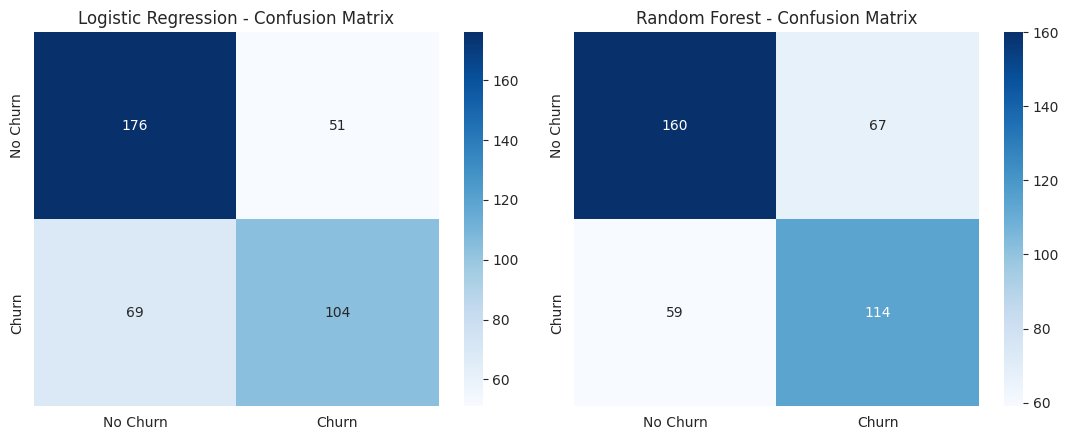

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (name, preds) in zip(axes, [("Logistic Regression", log_preds), ("Random Forest", rf_preds)]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["No Churn","Churn"], yticklabels=["No Churn","Churn"])
    ax.set_title(f"{name} - Confusion Matrix")

plt.tight_layout()
plt.show()

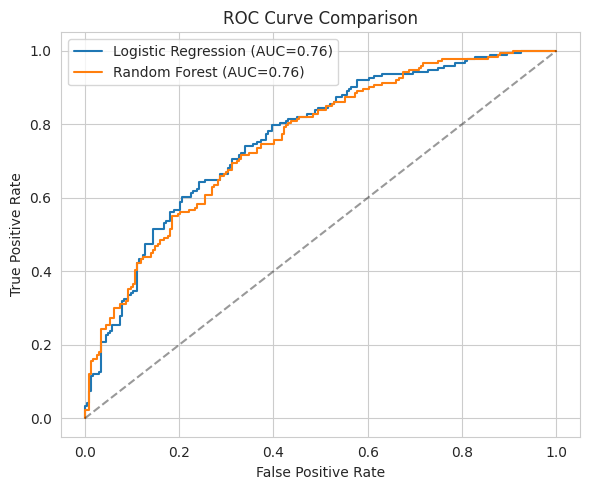

In [40]:
plt.figure(figsize=(6,5))

for name, proba in [("Logistic Regression", log_proba), ("Random Forest", rf_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.2f})")

plt.plot([0,1],[0,1],"k--", alpha=0.4)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.tight_layout()
plt.show()

**Result:** Random Forest catches more actual churners (Recall 0.66 vs 0.60) — more useful for this business case, even though Logistic Regression has slightly higher raw accuracy. This is exactly the kind of trade-off worth explaining in an interview: *"I picked the model that aligns with the business cost of a false negative, not just the highest accuracy."*

## 10. Feature Importance — what actually drives churn?

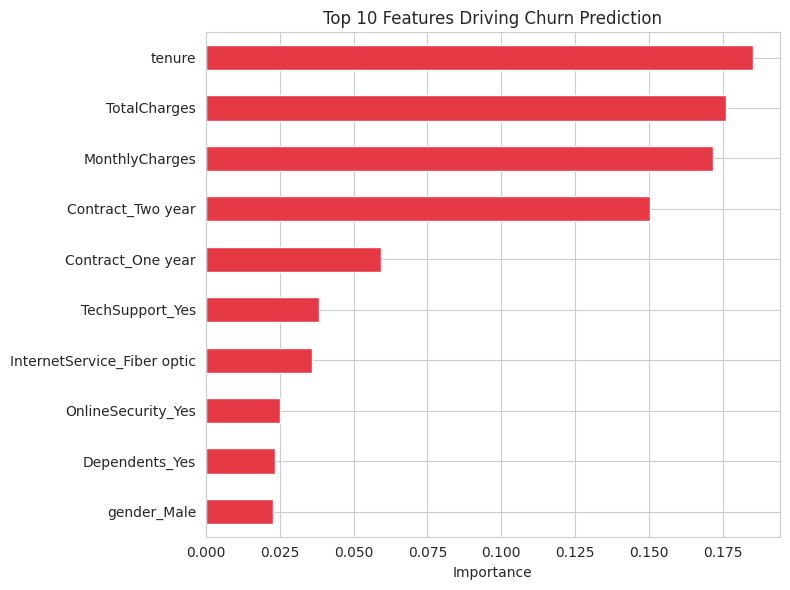

tenure                         0.185
TotalCharges                   0.176
MonthlyCharges                 0.172
Contract_Two year              0.150
Contract_One year              0.059
TechSupport_Yes                0.038
InternetService_Fiber optic    0.036
OnlineSecurity_Yes             0.025
Dependents_Yes                 0.023
gender_Male                    0.023
dtype: float64


In [42]:
importances = pd.Series(rf_model.feature_importances_, index=X_encoded.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind="barh", color="#E63946")
plt.title("Top 10 Features Driving Churn Prediction")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(top_features.round(3))

## 11. Business Recommendations- **Tenure and contract type are the strongest signals** — customers are most at risk in their first 12 months on month-to-month plans. Target this segment with early loyalty incentives (e.g. discount for switching to annual contract).- **High monthly charges + no tech support** is a risk combo — bundling free tech support for high-bill customers could reduce churn.- Because Random Forest gives well-ranked churn probabilities (not just yes/no), the business can sort customers by risk score and prioritize outreach to the top 10-20% — this is more useful in practice than a blunt yes/no flag.## Tech Stack`Python` · `Pandas` · `NumPy` · `Scikit-learn` · `Matplotlib` · `Seaborn`## What I'd do with more time- Hyperparameter tuning (GridSearchCV) for Random Forest- Try XGBoost / LightGBM for comparison- SHAP values for individual-customer explanations- Handle class imbalance more formally with SMOTE